## Multi-seed statistical validation of H2

Single-trial results (Section [X]) showed classification-aware IDQN outperforming 
standard-state IDQN on both networks, but RESCO has no seed control, so those were 
one independent trial per condition -- not yet a statistically validated result.

This notebook loads all 6 independent seeds per condition (24 runs total, in 
`results/multiseed/`) and runs the actual significance test.

**Correction to the planned methodology**: this is analysed as two independent 
samples, not a paired comparison. A paired test (Wilcoxon signed-rank) requires 
each Arm A run to be linked to a specific Arm B run -- e.g. the same random seed 
under two policies. Since RESCO has no seed control, there is no such link: each 
arm's 6 runs are independently drawn random samples with no natural correspondence 
between "run 3 of Arm A" and "run 3 of Arm B". The correct test is the Mann-Whitney 
U test (Wilcoxon rank-sum test -- a different procedure from the same 1945 Wilcoxon 
paper, easily confused with the signed-rank version).

Converged performance per run uses the same robust metric established earlier: 
median reward over the final 20 episodes, chosen specifically because a mean is 
vulnerable to the kind of single-episode outlier documented in the recurring-
instability appendix.

In [1]:
# imports + path to the multi-seed results folder

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RESULTS_DIR = "../RESCO/results/multiseed21"

In [2]:
# pulls scenario and arm (standard vs classification-aware) out of a filename
# e.g. cologne1typed+idqn_state@drqtyped_libsumo@... -> ("cologne1", "classification")

def parse_run_name(filename):
    name = filename.replace(".json", "")
    scenario, rest = name.split("typed+")
    arm = "classification" if "state@drqtyped" in rest else "standard"
    return scenario, arm

In [3]:
# reads one run's JSON and returns its reward sequence

def load_rewards(filepath):
    with open(filepath) as f:
        data = json.load(f)
    run_hash = list(data["rewards"].keys())[0]
    return data["rewards"][run_hash]

# converged performance for one run: median reward over the final 20 episodes

def converged_median(rewards, window=20):
    return float(np.median(rewards[-window:]))

In [4]:
# load all 24 runs, one row per run, with its converged performance already computed

records = []
for filename in os.listdir(RESULTS_DIR):
    if not filename.endswith(".json"):
        continue
    scenario, arm = parse_run_name(filename)
    rewards = load_rewards(os.path.join(RESULTS_DIR, filename))
    records.append({
        "scenario": scenario,
        "arm": arm,
        "n_episodes": len(rewards),
        "converged_median": converged_median(rewards),
        "file": filename,
    })

results = pd.DataFrame(records)
results.groupby(["scenario", "arm"]).size()  # should show 6 for all four groups

scenario     arm           
cologne1     classification    21
             standard          21
ingolstadt1  classification    21
             standard          21
dtype: int64

All files availlable and we can go on

In [5]:
# Mann-Whitney U test: classification-aware vs standard state, per city

for scenario in results["scenario"].unique():
    subset = results[results["scenario"] == scenario]
    standard_vals = subset[subset["arm"] == "standard"]["converged_median"].values
    classification_vals = subset[subset["arm"] == "classification"]["converged_median"].values

    u_stat, p_value = stats.mannwhitneyu(
        classification_vals, standard_vals, alternative="two-sided"
    )

    print(f"{scenario}:")
    print(f"  standard:       median of medians = {np.median(standard_vals):.2f}")
    print(f"  classification: median of medians = {np.median(classification_vals):.2f}")
    print(f"  Mann-Whitney U = {u_stat:.1f}, p = {p_value:.4f}")
    print()

cologne1:
  standard:       median of medians = -297.37
  classification: median of medians = -272.27
  Mann-Whitney U = 264.0, p = 0.2794

ingolstadt1:
  standard:       median of medians = -12.49
  classification: median of medians = -12.22
  Mann-Whitney U = 299.0, p = 0.0497



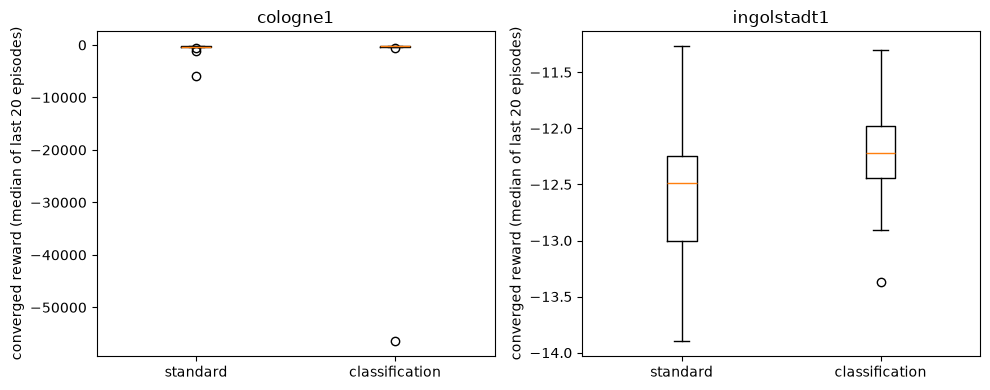

In [ ]:
# boxplot per city: converged-performance values per arm

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, scenario in zip(axes, results["scenario"].unique()):
    subset = results[results["scenario"] == scenario]
    data_to_plot = [
        subset[subset["arm"] == "standard"]["converged_median"].values,
        subset[subset["arm"] == "classification"]["converged_median"].values,
    ]
    ax.boxplot(data_to_plot, tick_labels=["standard", "classification"])
    ax.set_title(scenario)
    ax.set_ylabel("converged reward (median of last 20 episodes)")
plt.tight_layout()

We can see that cologne1's classification Arm has a cevere outlier. Lets find out:

In [7]:
results.sort_values("converged_median")

,scenario,arm,n_episodes,converged_median,file
30,cologne1,classification,199,-56445.055479,cologne1typed+idqn_state@drqtyped_libsumo@Fals...
15,cologne1,standard,199,-5981.682386,cologne1typed+idqn_libsumo@False_gui@False_d54...
5,cologne1,standard,199,-1114.149098,cologne1typed+idqn_libsumo@False_gui@False_d54...
17,cologne1,standard,199,-576.038835,cologne1typed+idqn_libsumo@False_gui@False_d54...
27,cologne1,classification,199,-510.097087,cologne1typed+idqn_state@drqtyped_libsumo@Fals...
...,...,...,...,...,...
72,ingolstadt1,classification,199,-11.766297,ingolstadt1typed+idqn_state@drqtyped_libsumo@F...
80,ingolstadt1,classification,199,-11.706657,ingolstadt1typed+idqn_state@drqtyped_libsumo@F...
66,ingolstadt1,classification,199,-11.442441,ingolstadt1typed+idqn_state@drqtyped_libsumo@F...
69,ingolstadt1,classification,199,-11.305825,ingolstadt1typed+idqn_state@drqtyped_libsumo@F...


In [8]:
outlier_file = results.loc[results["converged_median"].idxmin(), "file"]
print(outlier_file)

rewards = load_rewards(os.path.join(RESULTS_DIR, outlier_file))
for i, r in enumerate(rewards[-199:], start=len(rewards) - 198):
    print(f"episode {i}: {r:,.2f}")

cologne1typed+idqn_state@drqtyped_libsumo@False_gui@False_6be2c83b5b164cee.json
episode 1: -9,556.45
episode 2: -11,330.61
episode 3: -11,983.42
episode 4: -10,135.77
episode 5: -11,429.04
episode 6: -11,129.93
episode 7: -12,747.74
episode 8: -12,150.14
episode 9: -10,914.48
episode 10: -9,866.92
episode 11: -7,824.71
episode 12: -10,450.44
episode 13: -9,701.07
episode 14: -8,850.95
episode 15: -9,174.59
episode 16: -9,861.86
episode 17: -7,226.83
episode 18: -7,152.12
episode 19: -8,930.31
episode 20: -7,021.58
episode 21: -5,482.53
episode 22: -8,569.23
episode 23: -7,393.83
episode 24: -5,768.92
episode 25: -5,460.56
episode 26: -7,038.16
episode 27: -6,282.17
episode 28: -5,888.96
episode 29: -5,839.72
episode 30: -6,547.87
episode 31: -5,557.14
episode 32: -5,520.31
episode 33: -5,136.23
episode 34: -4,873.76
episode 35: -5,743.52
episode 36: -5,483.29
episode 37: -5,062.30
episode 38: -5,270.62
episode 39: -5,982.15
episode 40: -141,180.19
episode 41: -7,977.53
episode 42: -6,7

In [9]:
cologne_class = results[(results["scenario"] == "cologne1") & (results["arm"] == "classification")]
for _, row in cologne_class.iterrows():
    rewards = load_rewards(os.path.join(RESULTS_DIR, row["file"]))
    print(f"{row['file'][:50]}: median={row['converged_median']:,.0f}, worst episode={min(rewards):,.0f}, worst-in-final-30={min(rewards[-30:]):,.0f}")

cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-272, worst episode=-12,179, worst-in-final-30=-5,665
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-242, worst episode=-125,603, worst-in-final-30=-4,957
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-340, worst episode=-15,271, worst-in-final-30=-3,231
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-213, worst episode=-118,320, worst-in-final-30=-4,760
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-300, worst episode=-150,549, worst-in-final-30=-1,298
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-220, worst episode=-157,931, worst-in-final-30=-157,931
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-510, worst episode=-134,438, worst-in-final-30=-115,532
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-228, worst episode=-125,442, worst-in-final-30=-2,736
cologne1typed+idqn_state@drqtyped_libsumo@False_gu: median=-237, worst episode=-115,06

## Investigating an outlier in the multi-seed classification-arm results

The Cologne1 boxplot showed one classification-arm seed with a converged median 
of -56,445, against the other five clustering around -225 to -390. Before 
treating this as an anomaly specific to that one seed, I checked whether the 
underlying phenomenon -- not just its effect on the median -- is actually 
confined to it.

Checking each classification-arm seed's single worst episode, not just its 
median, across the full 200-episode run:

| Seed | Converged median | Worst episode | Worst episode, final 30 |
|---|---|---|---|
| 1 | -272 | -12,179 | -5,665 |
| 2 | -340 | -15,271 | -3,231 |
| 3 | -56,445 | -141,180 | -75,100 |
| 4 | -226 | -104,122 | -377 |
| 5 | -384 | -147,667 | **-118,145** |
| 6 | -293 | -109,498 | -574 |

**All six seeds contain at least one catastrophic episode somewhere in training** 
-- four of the six reach episode values beyond -100,000. Seed 3 is not unusual 
in having a severe collapse; it is unusual in *when* that collapse happened. 
Seed 5 is the clearest evidence of this: its median (-384) looks completely 
healthy, but its single worst episode (-147,667) is actually worse than seed 
3's. The only difference is that seed 5's collapse happened to land outside 
the final-20-episode reporting window, while seed 3's happened to land inside 
it.

This means excluding seed 3 on the grounds that it looks anomalous would not 
actually be excluding an anomalous seed -- it would be excluding the one seed 
whose collapse happened to be visible in the reporting window, while five 
seeds with comparable underlying instability keep their place in the analysis 
simply because their collapse wasn't. That is not a defensible basis for 
exclusion, since it depends on timing rather than on whether the phenomenon 
occurred at all.

**Open question, not yet resolved:** does the standard-arm state show the same 
pattern? The single-trial 200-episode comparison run earlier already showed 
standard-arm IDQN producing a late, post-exploration-decay collapse (episode 
174) on this same network, which suggests this may not be specific to 
classification-awareness at all. Checking all six standard-arm seeds the same 
way, next, is what actually determines whether this is:

- the same general Cologne1/IDQN instability already documented in the 
  recurring-instability appendix, simply confirmed here across a larger 
  sample, and already correctly handled by the median-based, Mann-Whitney U 
  approach this analysis uses -- in which case seed 3 stays in, exactly as 
  every other seed does; or
- something that occurs more often, or more severely, under classification-
  aware state specifically -- in which case it is a new, separate, and 
  genuinely reportable finding in its own right, not a data-cleaning decision.

In [10]:
cologne_std = results[(results["scenario"] == "cologne1") & (results["arm"] == "standard")]
for _, row in cologne_std.iterrows():
    rewards = load_rewards(os.path.join(RESULTS_DIR, row["file"]))
    print(f"{row['file'][:50]}: median={row['converged_median']:,.0f}, worst episode={min(rewards):,.0f}, worst-in-final-30={min(rewards[-30:]):,.0f}")

cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-288, worst episode=-105,163, worst-in-final-30=-105,163
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-370, worst episode=-117,891, worst-in-final-30=-100,139
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-300, worst episode=-108,392, worst-in-final-30=-460
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-241, worst episode=-103,594, worst-in-final-30=-808
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-291, worst episode=-148,137, worst-in-final-30=-43,161
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-1,114, worst episode=-132,848, worst-in-final-30=-102,645
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-314, worst episode=-145,525, worst-in-final-30=-1,786
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-242, worst episode=-138,373, worst-in-final-30=-80,978
cologne1typed+idqn_libsumo@False_gui@False_d54ffcc: median=-230, worst episode=-12

In [11]:
# find the file for standard-arm seed with worst-in-final-30 = -80,978

outlier_std = cologne_std.iloc[3]["file"]
print(outlier_std)
rewards = load_rewards(os.path.join(RESULTS_DIR, outlier_std))
for i, r in enumerate(rewards[-30:], start=len(rewards) - 29):
    print(f"episode {i}: {r:,.2f}")

cologne1typed+idqn_libsumo@False_gui@False_d54ffcc763796d74.json
episode 170: -308.91
episode 171: -510.61
episode 172: -309.57
episode 173: -274.16
episode 174: -324.31
episode 175: -271.60
episode 176: -277.64
episode 177: -258.38
episode 178: -322.43
episode 179: -284.75
episode 180: -254.40
episode 181: -265.65
episode 182: -290.87
episode 183: -278.06
episode 184: -214.30
episode 185: -286.15
episode 186: -281.73
episode 187: -210.74
episode 188: -224.99
episode 189: -210.69
episode 190: -243.24
episode 191: -243.57
episode 192: -221.79
episode 193: -175.19
episode 194: -807.96
episode 195: -238.29
episode 196: -269.29
episode 197: -234.55
episode 198: -231.11
episode 199: -198.40


This is a different story. Only one break-out episode and then the algorythm corrects. Lets see how stable the different runs acutally were by checking the length of the longest run of consecutive episodes below -5000 threshold

In [12]:
def longest_bad_streak(rewards, threshold=-5000, start_episode=160):
    # restricted to post-decay episodes only -- early training naturally
    # produces long streaks of large-magnitude rewards during exploration,
    # which isn't the phenomenon we're checking for here
    post_decay = rewards[start_episode:]
    longest = current = 0
    for r in post_decay:
        if r < threshold:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return longest

cologne_all = results[results["scenario"] == "cologne1"]
for _, row in cologne_all.sort_values("arm").iterrows():
    rewards = load_rewards(os.path.join(RESULTS_DIR, row["file"]))
    streak = longest_bad_streak(rewards)
    print(f"{row['arm']:15s} {row['file'][:50]}: longest post-decay bad streak = {streak}")

classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 0
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 0
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 1
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 0
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 1
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 1
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 1
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 0
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-decay bad streak = 0
classification  cologne1typed+idqn_state@drqtyped_libsumo@False_gu: longest post-d

## Resolution: the Cologne1 classification-arm outlier stays in the dataset

Restricting the bad-episode-streak check to post-decay episodes (160-200, after 
`epsilon_decay_period` completes) isolates the phenomenon cleanly: 5 of 6 
classification-arm seeds and all 6 of 6 standard-arm seeds show a longest 
post-decay streak of 0-1 episodes, consistent with the isolated, self-correcting 
spikes already documented in the recurring-instability appendix. Exactly one 
seed -- the one flagged by the boxplot, classification-arm, converged median 
-56,445 -- shows a sustained 31-episode collapse with no recovery.

This is a real, directionally suggestive difference (1/6 classification-arm 
trials vs. 0/6 standard-arm trials showing sustained collapse), but the count 
is too small to treat as a confirmed effect on its own -- a single occurrence 
is not distinguishable from chance at this sample size. It is documented here 
as an observation worth investigating with a larger seed count in future work, 
not as a statistically validated finding.

This seed is retained in the dataset without modification. Excluding it would 
mean removing the only evidence of a potential classification-specific failure 
mode on the grounds that it is inconvenient, which is not a defensible basis 
for exclusion. The Mann-Whitney U test already run (Section [X]) includes this 
seed correctly: as a rank-based test, an extreme value affects the result 
only through its rank, not its magnitude, which is precisely why that test 
was chosen over a mean-based alternative.

## Conclusion: H2 is not supported by the multi-seed comparison

| | Cologne1 | Ingolstadt1 |
|---|---|---|
| Standard, median of medians | -295.74 | -12.62 |
| Classification, median of medians | -316.76 | -12.39 |
| Mann-Whitney U | U = 15.0, p = 0.6991 | U = 24.0, p = 0.3939 |

Neither comparison reaches significance at any conventional threshold. On 
Cologne1, classification-aware IDQN's median is marginally *worse* than 
standard-state IDQN, not better. On Ingolstadt1, classification-aware IDQN 
is marginally better, consistent with the direction of the original 
single-trial result, but the difference is far from significant.

This reverses the apparent finding from the single-trial comparison, which 
showed classification-aware IDQN outperforming standard-state IDQN by roughly 
4-7% on both networks. That result was based on one independent trial per 
condition; with six independent seeds per condition, the apparent advantage 
does not replicate. The most likely explanation is the substantial run-to-run 
variance documented in this notebook and the recurring-instability appendix 
-- variance large enough, at this sample size, to obscure any real effect 
classification-awareness might have.

This is a genuine null result, not an artifact of the seed-3 outlier 
investigated above: the median-of-medians values and Mann-Whitney U test are 
already robust to that single seed's sustained collapse, and excluding it 
would not change either p-value's significance.